Per iniziare importiamo nel nostro programma la libreria pandas per la manipolazione dei dataframe, una libreria di Hugging Face per scaricare dataset direttamente dalla repository e infine importiamo dalla libreria transformers l'astrazione di una pipeline di NLP per il task di Sentiment Analysis

In [ ]:
import pandas as pd
from datasets import load_dataset
from transformers import pipeline

carichiamo i due subset del database acquisendone i dati e trasformandoli in tabelle pandas(DataFrame).
Inoltre selezioniamo lo split di training per avere un campione vasto e affidabile per la validazione che andremo a fare in un secondo momento.

In [ ]:
print("1. Scaricamento dati in corso...")
dataset_posts = load_dataset("NLP-POL/instagram-political-communication-it", "posts")
df_posts = pd.DataFrame(dataset_posts['train'])

dataset_comments = load_dataset("NLP-POL/instagram-political-communication-it", "comments")
df_comments = pd.DataFrame(dataset_comments['train'])

print(f"Post: {len(df_posts)} | Commenti: {len(df_comments)}")

1. Scaricamento dati in corso...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Resolving data files:   0%|          | 0/34 [00:00<?, ?it/s]

Post: 73585 | Commenti: 674277


Per recuperare la goldlabel identificata con valori 0-1 nel database creiamo una lista con i nomi delle colonne del dataframe che ci interessano. Usiamo la funzione idmax per identificare la colonna col valore massimo per ogni riga  (axis=1 affinchè confronti i valori nell'asse orizzontale) e infine puliamo attraverso la funzione replace la stringa risultante in modo più intuitivo.

Questa estrazione ci serve per un test di validazione dell'affidabilità del modello, attraverso il quale confronteremo la sentiment indicata nel database con quella assegnata dal modello scelto.





In [ ]:
colonne_sentiment = ['sentiment_negative', 'sentiment_neutral', 'sentiment_positive']
df_posts['gold_label'] = df_posts[colonne_sentiment].idxmax(axis=1)
df_posts['gold_label'] = df_posts['gold_label'].str.replace('sentiment_', '')

Carichiamo il modello selezionato e l'astrazione della pipeline per la sentiment analysis. Device=0 indica a Python di usare la GPU per velocizzare il processo

In [ ]:
print("Caricamento Modello...")
sentiment_task = pipeline(
    "sentiment-analysis",
    model="cardiffnlp/twitter-xlm-roberta-base-sentiment",
    device=0
)

Caricamento IA...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

XLMRobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-xlm-roberta-base-sentiment
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Creiamo un dataframe di validazione composto da un sample randomico di post sempre uguale (utile al fine della riproducibilità dei risultati) che viene salvato in una copia dello stesso dataframe.
Creaiamo una variabile nella quale estraiamo dalla colonna 'caption' dal dataframe di validazione delle stringhe da inserire in una lista che diamo in pasto al modello XML-RoBERTa. Il modello avvia la procedura di tokenizzazione per poi trasformare i token in vettori e calcolare la probabilità che questo vettore appartenga a uno delle tre classi precedentemente indicate. L'output sarà una lista di dizionari da cui per ogni dizionario estraiamo la label (in minuscolo per mantenere la stessa denominazione del database). Proseguiamo infine con una visualizzazione tabellare esemplificativa del confronto attraverso la funzione display.

In [ ]:
df_val = df_posts.sample(300, random_state=42).copy()
print(f"Analisi di validazione su {len(df_val)} post...")

testi_post = df_val['caption'].tolist()
predizioni_val = sentiment_task(testi_post, truncation=True, max_length=512)

df_val['ia_label'] = [p['label'].lower() for p in predizioni_val]

#Visualizziamo il confronto
print("\nCONFRONTO DI VALIDAZIONE (PRIME 10 RIGHE)")
display(df_val[['caption', 'gold_label', 'ia_label']].head(10))


Analisi di validazione su 300 post...

CONFRONTO DI VALIDAZIONE (PRIME 10 RIGHE)


,caption,gold_label,ia_label
65518,"Un'elezione rapida, quella di Papa Leone XIV, ...",positive,positive
48139,"Pochi giorni fa, su un treno Frecciarossa Bari...",positive,neutral
37042,❌❌❌ Ringrazio i poliziotti della Squadra Mobil...,negative,negative
60537,Un’emozione straordinaria per il piccolo Tomma...,positive,positive
27404,Davanti alle indecenti violenze dei criminali ...,negative,negative
70096,Il #referendum è stato solo un altro capitolo ...,negative,negative
50590,"Investimenti, competenze e difesa.\nNe ho parl...",positive,neutral
22777,𝐏𝐞𝐫𝐜𝐡𝐞' 𝐜'𝐞' 𝐛𝐢𝐬𝐨𝐠𝐧𝐨 𝐝𝐢 𝐟𝐢𝐧𝐚𝐧𝐳𝐢𝐚𝐫𝐞 𝐢𝐧 𝐦𝐨𝐝𝐨 𝐜𝐨𝐬...,negative,negative
11455,📍 La settimana in Parlamento\n\nIn Aula: merca...,positive,neutral
31472,"La politica, quella vera, nasce dall’ascolto, ...",positive,positive


Importiamo da una libreria per il Machine Learning una funzione di calcolo (confusion matrix) per contare gli errori e una funzione di classificazione per calcolare le percentuali di Precision, Recall e F-1. Quindi creiamo una tabella di report che genera i valori di Precision (quante volte ha ragione il modello nell'indicare un'etichetta), Recall (quanti casi di un'etichetta il modello trova rispetto al totale del database contrassegnati con la stessa etichetta), F-1 (la media tra le due).
Analizzando questi valori possiamo dichiarare che il modello caricato presenta una tendenza a classificare più polarizzata (negative/positive) rispetto alla classificazione del database.
Vi è inoltre una recall discreta dei post con gold label positiva. Quest'ultimo fenomeno probabilmente a causa di una sentiment positiva indicata nel database espressa in maniera implicita o senza l'uso di termini chiave.
La media pesata degli f1-score dà comunque valori di affidabilità sufficiente per proseguire, condizionata al ribasso dagli scarsi valori per i post di sentiment neutro.

REPORT DI VALIDAZIONE
              precision    recall  f1-score   support

    negative       0.78      0.78      0.78       104
     neutral       0.01      0.33      0.02         3
    positive       0.91      0.55      0.68       193

    accuracy                           0.63       300
   macro avg       0.57      0.55      0.50       300
weighted avg       0.85      0.63      0.71       300



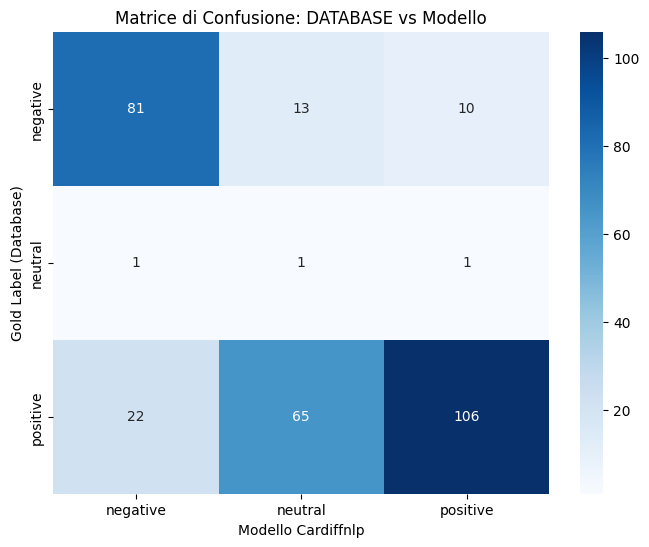

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
#classification_report
report = classification_report(df_val['gold_label'], df_val['ia_label'])
print("REPORT DI VALIDAZIONE")
print(report)
#confusion_matrix
labels = ['negative', 'neutral', 'positive']
cm = confusion_matrix(df_val['gold_label'], df_val['ia_label'], labels=labels)
#heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels)
plt.title('Matrice di Confusione: DATABASE vs Modello')
plt.xlabel('Modello Cardiffnlp')
plt.ylabel('Gold Label (Database)')
plt.show()

Una volta validato il modello proseguiamo costruendo il dataframe da analizzare. è necessario perciò collegare i commenti ai rispettivi autori dei post, perché i due dati si trovano in tabelle separate. Per prima cosa, creiamo un dizionario in cui, attraverso un ciclo sulle righe dei post, memorizziamo ogni ID univoco del post come 'chiave' e il nome del politico come 'valore'. Successivamente, per ogni commento, il codice verifica se l'ID del post a cui si riferisce è presente nel dizionario. Se esiste, estrae il nome del politico, altrimenti assegna l'etichetta 'Sconosciuto' per evitare errori. Infine, tutti i nomi trovati sono stati inseriti in una nuova colonna del dataset commenti (post_author).

In [ ]:
dizionario_autori = {}

for indice, riga in df_posts.iterrows():
    codice_post = riga['_id']
    nome_politico = riga['author']

    dizionario_autori[codice_post] = nome_politico

autori_post_dei_commenti = []

for indice, riga in df_comments.iterrows():
    id_del_post = riga['post_info__id']

    # verifichiamo se questo ID è presente nel nostro dizionario
    if id_del_post in dizionario_autori:
        nome_politico = dizionario_autori[id_del_post]
    else:
        nome_politico = "Sconosciuto"

    autori_post_dei_commenti.append(nome_politico)

df_comments['post_author'] = autori_post_dei_commenti

Una volta associati i dati, ho ritenuto necessario fare un'analisi volumetrica per selezionare un campione di autori che avessero un numero consistente di post e commenti(engagement). Attraverso la funzione di pandas value_counts ho raccolto i valori per costruire una tabella in cui per ogni politico stampasse il n.post, n.commenti, e una media di commenti per post. Infine selezioniamo le prime venti righe di un dataframe (df_analisi) ordinato in ordine decrescente per la media di commenti per i post.

In [ ]:
conteggio_post = df_posts['author'].value_counts()

conteggio_commenti = df_comments['post_author'].value_counts()

df_analisi = pd.DataFrame({
    'Post_Totali': conteggio_post,
    'Commenti_Totali': conteggio_commenti
})
df_analisi['Media_Commenti_per_Post'] = (df_analisi['Commenti_Totali'] / df_analisi['Post_Totali']).round(2)

# ordiniamo la tabella per avere in alto chi ha il rapporto più alto
tabella_finale = df_analisi.sort_values(by='Media_Commenti_per_Post', ascending=False)
print("CLASSIFICA ENGAGEMENT: CHI GENERA PIÙ DISCUSSIONE?")
display(tabella_finale.head(20))

CLASSIFICA ENGAGEMENT: CHI GENERA PIÙ DISCUSSIONE?


,Post_Totali,Commenti_Totali,Media_Commenti_per_Post
giorgiameloni,765.0,57660.0,75.37
giuseppeconte_ufficiale,744.0,52463.0,70.51
ellyesse,705.0,48065.0,68.18
matteosalviniofficial,1839.0,111082.0,60.40
matteorenzi,501.0,29568.0,59.02
crosettoguido,73.0,3733.0,51.14
antoniotajani,441.0,21108.0,47.86
mariaelenaboschi_official,89.0,4222.0,47.44
chiara_appendino,89.0,3365.0,37.81
marcofurfaro,188.0,6993.0,37.20


Una volta visionati i primi 20 politici, applichiamo un ulteriore filtro per prendere in esame i primi 10 politici che abbiano almeno 500 post. I nomi di questi politici vengono estratti e e convertiti in una lista in modo da sottoporli a un ciclo for. L'iterazione prevede che per ogni politico vengano estratti i primi 500 post nella condizione per la quale la stringa della colonna 'author' corrisponda all'elemento della lista (definito politico), all'interno un altro ciclo for prevede che per ognuno di questi post si recuperi dal dataframe dei commenti i primi 10 commenti secondo la corrispondenza tra 'post_info_id' e l''_id' del post e li inserisce in una lista per poi reiterarli concatenandoli attraverso un ciclo for nella variabile stringa_commenti. Il risultato viene unito al contenuto della colonna 'caption' relativa al post per formare un testo concatenato da dare in pasto al modello. Popoliamo quindi la lista creata a inizio blocco con dei dizionari che prevedano al proprio interno: politico, gold label, caption, e testo concatenato. La lista viene quindi usata per creare il nostro nuovo dataframe di riferimento.

In [ ]:
tabella_filtrata_per_post = tabella_finale[tabella_finale['Post_Totali'] > 500]
top_10_nomi = tabella_filtrata_per_post.head(10).index.tolist()

lista_confronto = []

for politico in top_10_nomi:
    df_politico = df_posts[df_posts['author'] == politico].head(500)

    for index, post in df_politico.iterrows():
        # recuperiamo i commenti relativi a questo specifico post
        filtro_commenti = df_comments[df_comments['post_info__id'] == post['_id']]
        testi_commenti = filtro_commenti['text'].head(10).tolist()

        # concateniamo i commenti in un unico blocco di testo
        stringa_commenti = ""
        for c in testi_commenti:
            stringa_commenti = stringa_commenti + " " + str(c)

        # creiamo il testo concatenato (Post + Commenti)
        testo_concatenato = str(post['caption']) + " [SEP] " + stringa_commenti

        lista_confronto.append({
            'Politico': politico,
            'Sentiment_Post_Originale': post['gold_label'], # Usiamo la gold label già calcolata
            'Testo_Solo_Post': str(post['caption']),
            'Testo_Post_e_Commenti': testo_concatenato
        })

df_comparazione = pd.DataFrame(lista_confronto)
print(f"Creato dataset di confronto con {len(df_comparazione)} righe.")

Creato dataset di confronto con 5000 righe.


Estratti in una lista solo le stringhe concatenate di post e commenti, le diamo in pasto alla pipeline del modello validato precedentemente ponendo dei vincoli di grandezza (l'analisi non procede se non vincolata a una lunghezza massima). Per ognuno di queste computazioni inseriamo la label risultante in una nuova colonna del dataframe che chiamiamo 'Sentiment_Interazione'. A questo punto definiamo una funzione che confronti la sentiment del post con la sentiment del post concatenato ai commenti che restituisca in una nuova colonna del df(attraverso la funzione apply corredata dall'argomento axis=1 per applicare il confronto a due valori della stessa riga e non nell'asse della colonna) l'allineamento o il dissenso tra i due. Inseriamo l'esito in una nuova colonna del df denominata 'Risultato'. Per il report ho infine aggregato i dati per 'Politico' e contato attraverso la funzione .size il numero di volte che appaiono le diverse combinazioni. La funzione di Pandas .unstack trasforma i dati in una tabella da visualizzare. Infine è stato calcolato il rapporto casi di allineamento e di dissenso per estrapolare una normalizzazione percentuale.

In [ ]:
print("Il modello sta analizzando le interazioni del pubblico...")
testi_da_analizzare = df_comparazione['Testo_Post_e_Commenti'].tolist()
sentiment_testo_concatenato = sentiment_task(testi_da_analizzare, truncation=True, max_length=512, batch_size=8)
df_comparazione['Sentiment_Interazione'] = [p['label'].lower() for p in sentiment_testo_concatenato]

def verifica_coerenza(row):
    if row['Sentiment_Post_Originale'] == row['Sentiment_Interazione']:
        return "Allineamento al sentiment originale"
    else:
        return "Dissenso al sentiment originale"

df_comparazione['Risultato'] = df_comparazione.apply(verifica_coerenza, axis=1)

# Report finale per Politico
report_finale = df_comparazione.groupby(['Politico', 'Risultato']).size().unstack(fill_value=0)
report_finale['%_Dissenso'] = (report_finale['Dissenso al sentiment originale'] /
                                     (report_finale['Allineamento al sentiment originale'] + report_finale['Dissenso al sentiment originale']) * 100).round(2)

print("ANALISI DELLA REAZIONE DEI COMMENTATORI")
display(report_finale.sort_values(by='%_Dissenso', ascending=False))

L'IA sta analizzando le interazioni del pubblico...
ANALISI DELLA REAZIONE DEI COMMENTATORI


Risultato,Allineamento al sentiment originale,Dissenso al sentiment originale,%_Dissenso
Politico,,,
francescolollobrigida,262,238,47.6
andrea_delmastro,277,223,44.6
giorgiameloni,280,220,44.0
matteosalviniofficial,309,191,38.2
galeazzo_bignami,311,189,37.8
ellyesse,315,185,37.0
augustamontaruli,328,172,34.4
giuseppeconte_ufficiale,342,158,31.6
matteorenzi,360,140,28.0
